In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append("..")
from src.data_preprocessing import load_data, remove_unwanted_columns, convert_to_datetime, sort_by_date_and_productId, lag_features, drop_null_values
from src.split_data import split_data, split_features_and_target

In [2]:
df = load_data("../data/raw/stocksense_dataset.csv")
df.head()

,date,product_id,product_name,category,price,quantity_sold,stock_before,stock_after,reorder_level
0,2024-01-01,P001,Rice,Grains,1502,13,121,108,30
1,2024-01-01,P002,Milk,Dairy,1288,11,124,113,30
2,2024-01-01,P003,Bread,Bakery,902,14,180,166,30
3,2024-01-01,P004,Sugar,Groceries,1049,16,70,54,30
4,2024-01-01,P005,Eggs,Protein,2060,8,138,130,30


In [3]:
df = remove_unwanted_columns(df, ["category", "stock_before", "reorder_level"])


df.head()

,date,product_id,product_name,price,quantity_sold,stock_after
0,2024-01-01,P001,Rice,1502,13,108
1,2024-01-01,P002,Milk,1288,11,113
2,2024-01-01,P003,Bread,902,14,166
3,2024-01-01,P004,Sugar,1049,16,54
4,2024-01-01,P005,Eggs,2060,8,130


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           900 non-null    object
 1   product_id     900 non-null    object
 2   product_name   900 non-null    object
 3   price          900 non-null    int64 
 4   quantity_sold  900 non-null    int64 
 5   stock_after    900 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 42.3+ KB


In [5]:
df = convert_to_datetime(df, "date")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           900 non-null    datetime64[ns]
 1   product_id     900 non-null    object        
 2   product_name   900 non-null    object        
 3   price          900 non-null    int64         
 4   quantity_sold  900 non-null    int64         
 5   stock_after    900 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 42.3+ KB


In [6]:
df.isnull().sum()

date             0
product_id       0
product_name     0
price            0
quantity_sold    0
stock_after      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['product_name'].nunique()

5

In [9]:
df = sort_by_date_and_productId(df, "date", "product_id")

df.head()

,date,product_id,product_name,price,quantity_sold,stock_after
0,2024-01-01,P001,Rice,1502,13,108
1,2024-01-01,P002,Milk,1288,11,113
2,2024-01-01,P003,Bread,902,14,166
3,2024-01-01,P004,Sugar,1049,16,54
4,2024-01-01,P005,Eggs,2060,8,130


In [10]:
print((df['price'] < 0).sum())
print((df['stock_after'] < 0).sum())
print((df['quantity_sold'] < 0).sum())

0
0
0


In [11]:
df.describe()

,date,price,quantity_sold,stock_after
count,900,900.000000,900.000000,900.000000
mean,2024-03-30 11:59:59.999999744,1320.036667,10.036667,116.388889
min,2024-01-01 00:00:00,700.000000,2.000000,36.000000
25%,2024-02-14 18:00:00,964.500000,7.000000,78.000000
50%,2024-03-30 12:00:00,1213.500000,10.000000,118.000000
75%,2024-05-14 06:00:00,1579.250000,12.000000,153.250000
max,2024-06-28 00:00:00,2149.000000,25.000000,196.000000
std,NaN,428.121527,3.785663,43.886646


In [12]:
lag_features(df, "product_id", "quantity_sold")

df.head()

,date,product_id,product_name,price,quantity_sold,stock_after,quantity_sold_lag
0,2024-01-01,P001,Rice,1502,13,108,10.0
1,2024-01-01,P002,Milk,1288,11,113,5.0
2,2024-01-01,P003,Bread,902,14,166,14.0
3,2024-01-01,P004,Sugar,1049,16,54,11.0
4,2024-01-01,P005,Eggs,2060,8,130,7.0


In [13]:
df.isnull().sum()

date                 0
product_id           0
product_name         0
price                0
quantity_sold        0
stock_after          0
quantity_sold_lag    5
dtype: int64

In [14]:
df = drop_null_values(df)
df.isnull().sum()

date                 0
product_id           0
product_name         0
price                0
quantity_sold        0
stock_after          0
quantity_sold_lag    0
dtype: int64

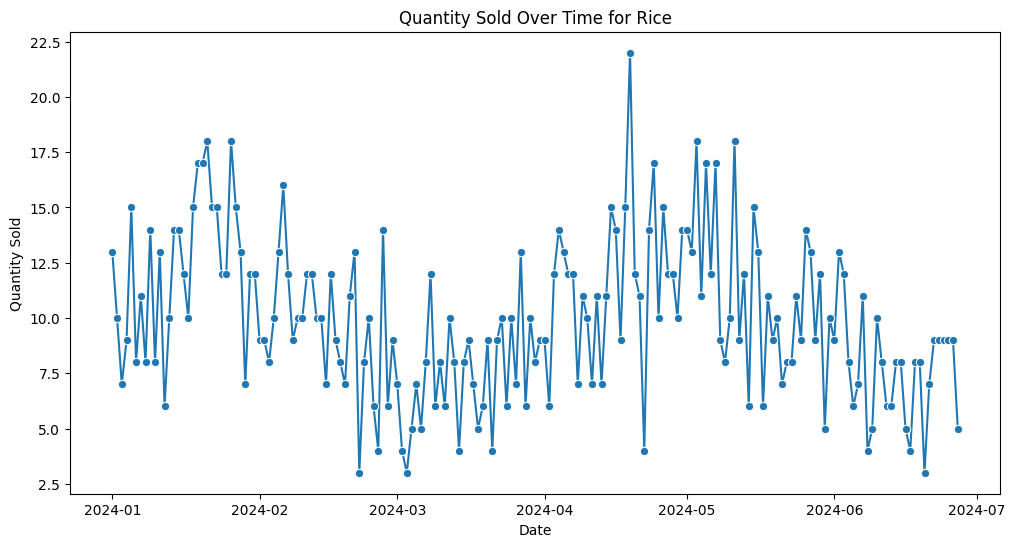

In [15]:
sample = df[df['product_id'] == 'P001']

plt.figure(figsize=(12, 6))

sns.lineplot(x='date', y='quantity_sold', data=sample, marker='o')
plt.title(f'Quantity Sold Over Time for {sample["product_name"].iloc[0]}')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.show()


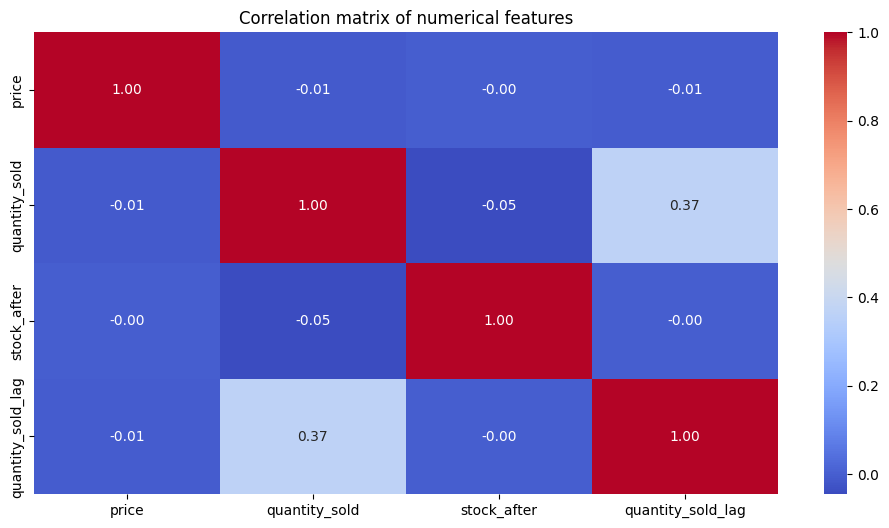

In [16]:
num_cols = df.select_dtypes(include=[np.number]).columns

correlation = df[num_cols].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix of numerical features")
plt.show()

In [26]:
df.shape

(895, 7)

In [17]:
train_df, val_df, test_df =split_data(df)

In [18]:
test_df.max()

date                 2024-06-27 00:00:00
product_id                          P005
product_name                       Sugar
price                               2148
quantity_sold                         13
stock_after                          193
quantity_sold_lag                   13.0
dtype: object

In [22]:
X_train, y_train =split_features_and_target(train_df)
X_val, y_val =split_features_and_target(val_df)
X_test, y_test =split_features_and_target(test_df)

In [24]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(626, 6)
(134, 6)
(135, 6)
